# Audience Sensitivity, Content Compliance & Format Preference Analysis of France Top 50 Playlist

**Atlantic Recording Corporation — France Top 50 Analysis**

This notebook takes the project from:

**Raw CSV → Data Validation → Data Cleaning → Feature Engineering → EDA → KPI Analysis → Statistical Testing → Insights → Exported Results → Streamlit App**

### Important methodological note
This dataset is a daily France Top 50 snapshot dataset. It can show **association with chart representation/rank**, but it does not directly measure listener preference or causality.

The notebook defines the project-specific **Clean Dominance Ratio**, **Album Size Impact Index**, and **Content Acceptance Score** transparently.


## 1. Setup and Imports

In [ ]:
# Install required libraries for Google Colab
!pip -q install pandas numpy matplotlib seaborn scipy plotly streamlit pyngrok scikit-learn


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from pathlib import Path
from google.colab import files
from IPython.display import display, HTML

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Upload and Load the CSV

In [ ]:
# Upload the Atlantic France CSV
uploaded = files.upload()

print("Uploaded files:")
for file_name in uploaded.keys():
    print(" -", file_name)


Saving Atlantic_France.csv to Atlantic_France.csv
Uploaded files:
 - Atlantic_France.csv


In [ ]:
# Load the uploaded CSV
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully.
Shape: (27800, 10)


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,LA RUE,No Limit & Gazo & Damso,72,225137,single,1,True,https://i.scdn.co/image/ab67616d0000b27384f245...
1,18-05-2024,2,C'est carré le S,Naps,74,201533,album,22,False,https://i.scdn.co/image/ab67616d0000b27348f7c1...
2,18-05-2024,3,Freestyle LVL UP 1,Ninho,76,114182,single,1,True,https://i.scdn.co/image/ab67616d0000b273fbe613...
3,18-05-2024,4,Bolide allemand,SDM,79,176746,album,15,True,https://i.scdn.co/image/ab67616d0000b273455e89...
4,18-05-2024,5,Freestyle LVL UP 2,Ninho,71,149064,single,1,True,https://i.scdn.co/image/ab67616d0000b27351f1cb...


## 3. Initial Data Inspection

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


Dataset Shape: (27800, 10)

Columns:
['date', 'position', 'song', 'artist', 'popularity', 'duration_ms', 'album_type', 'total_tracks', 'is_explicit', 'album_cover_url']

Data Types:
date               object
position            int64
song               object
artist             object
popularity          int64
duration_ms         int64
album_type         object
total_tracks        int64
is_explicit          bool
album_cover_url    object
dtype: object

Missing Values:


,0
date,0
position,0
song,1
artist,0
popularity,0
duration_ms,0
album_type,0
total_tracks,0
is_explicit,0
album_cover_url,0



Duplicate Rows: 19


In [ ]:
print("Descriptive Statistics")
display(df.describe(include="all").T)

print("\nUnique Dates:", df["date"].nunique())
print("Unique Songs:", df["song"].nunique())
print("Unique Artists:", df["artist"].nunique())

print("\nAlbum Types:")
display(df["album_type"].value_counts())

print("\nExplicit Content:")
display(df["is_explicit"].value_counts(dropna=False))


Descriptive Statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,27800,555,01-03-2025,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
position,27800.0,NaN,NaN,NaN,25.5,14.431129,1.0,13.0,25.5,38.0,50.0
song,27799,695,Laboratoire,458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artist,27800,325,Werenoi,2206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,27800.0,NaN,NaN,NaN,76.645108,11.570874,0.0,71.0,75.0,83.0,100.0
duration_ms,27800.0,NaN,NaN,NaN,185474.848165,32436.845058,0.0,165586.0,180000.0,207733.0,547413.0
album_type,27800,3,album,14695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_tracks,27800.0,NaN,NaN,NaN,8.999856,8.14006,1.0,1.0,10.0,15.0,119.0
is_explicit,27800,2,True,15640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_cover_url,27800,542,https://i.scdn.co/image/ab67616d0000b273455e89...,576,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Unique Dates: 555
Unique Songs: 695
Unique Artists: 325

Album Types:


,count
album_type,
album,14695
single,13096
compilation,9



Explicit Content:


,count
is_explicit,
True,15640
False,12160


## 4. Data Validation

In [ ]:
# Convert date to datetime
df["date"] = pd.to_datetime(
    df["date"],
    format="%d-%m-%Y",
    errors="coerce"
)

print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Number of unique dates:", df["date"].nunique())


Date range: 2024-05-18 to 2025-11-27
Number of unique dates: 555


In [ ]:
# Validate number of records per day
daily_counts = df.groupby("date").size()

print("Daily record-count summary:")
display(daily_counts.describe())

print("\nDates with record count != 50:")
display(daily_counts[daily_counts != 50])


Daily record-count summary:


,0
count,555.000000
mean,50.090090
std,2.122382
min,50.000000
25%,50.000000
50%,50.000000
75%,50.000000
max,100.000000



Dates with record count != 50:


,0
date,
2025-03-01,100


In [ ]:
# Validate duplicate date-position combinations
duplicate_date_position = df.duplicated(
    subset=["date", "position"],
    keep=False
)

print("Duplicate date-position records:", duplicate_date_position.sum())

if duplicate_date_position.sum() > 0:
    display(
        df.loc[
            duplicate_date_position,
            ["date", "position", "song", "artist", "popularity"]
        ].sort_values(["date", "position"]).head(30)
    )


Duplicate date-position records: 100


,date,position,song,artist,popularity
14350,2025-03-01,1,Pyramide,Werenoi,78
14400,2025-03-01,1,Pyramide,Werenoi,78
14351,2025-03-01,2,Petit génie,Jungeli & Imen Es & Alonzo,84
14401,2025-03-01,2,Petit génie,Jungeli & Imen Es & Alonzo,84
14352,2025-03-01,3,Ceux qu'on était,Pierre Garnier,82
14402,2025-03-01,3,Ceux qu'on était,Pierre Garnier,82
14353,2025-03-01,4,FLASHBACK,Favé,79
14403,2025-03-01,4,I love you,Dadju & Tayc,69
14354,2025-03-01,5,I love you,Dadju & Tayc,69
14404,2025-03-01,5,FLASHBACK,Favé,79


### Known data-quality issue: 1 March 2025

The source contains 100 rows for 1 March 2025 instead of 50. This means that date contains two 50-row snapshots.

For this project we retain the **first 50 records** for that date so every date has equal weight and the final dataset contains exactly **50 rows per day**.

This decision should be documented in the research paper.


In [ ]:
# Inspect the duplicated date
march_1 = df[df["date"] == pd.Timestamp("2025-03-01")].copy()

print("Rows on 1 March 2025:", len(march_1))
display(
    march_1[["position", "song", "artist", "popularity", "album_type"]].head(100)
)


Rows on 1 March 2025: 100


,position,song,artist,popularity,album_type
14350,1,Pyramide,Werenoi,78,album
14351,2,Petit génie,Jungeli & Imen Es & Alonzo,84,single
14352,3,Ceux qu'on était,Pierre Garnier,82,single
14353,4,FLASHBACK,Favé,79,album
14354,5,I love you,Dadju & Tayc,69,album
14355,6,Beautiful Things,Benson Boone,100,single
14356,7,MAMI WATA,Gazo & Tiakola,79,album
14357,8,Tu connais,Werenoi,74,album
14358,9,Lose Control,Teddy Swims,94,album
14359,10,Si No Estás,iñigo quintero,93,single


In [ ]:
# Retain the first 50-row snapshot for 1 March 2025
march_1_rows = df[df["date"] == pd.Timestamp("2025-03-01")]
first_snapshot = march_1_rows.iloc[:50].copy()

other_dates = df[df["date"] != pd.Timestamp("2025-03-01")].copy()

df_clean = pd.concat(
    [other_dates, first_snapshot],
    ignore_index=True
)

print("Rows before March 1 correction:", len(df))
print("Rows after March 1 correction:", len(df_clean))


Rows before March 1 correction: 27800
Rows after March 1 correction: 27750


## 5. Data Cleaning and Standardization

In [ ]:
# Inspect missing values before cleaning
print("Missing values before cleaning:")
display(df_clean.isnull().sum())


Missing values before cleaning:


,0
date,0
position,0
song,1
artist,0
popularity,0
duration_ms,0
album_type,0
total_tracks,0
is_explicit,0
album_cover_url,0


In [ ]:
# Remove records with missing song title
missing_song_count = df_clean["song"].isnull().sum()
print("Rows with missing song title:", missing_song_count)

df_clean = df_clean.dropna(subset=["song"]).copy()

print("Rows after removing missing song:", len(df_clean))


Rows with missing song title: 1
Rows after removing missing song: 27749


In [ ]:
# Standardize album type labels
df_clean["album_type"] = (
    df_clean["album_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Convert duration from milliseconds to minutes
df_clean["duration_min"] = df_clean["duration_ms"] / 60000

# Treat zero/negative durations as invalid
df_clean.loc[
    df_clean["duration_ms"] <= 0,
    "duration_min"
] = np.nan

print("Album types after standardization:")
display(df_clean["album_type"].value_counts())

print("\nInvalid/non-positive durations:",
      (df_clean["duration_ms"] <= 0).sum())


Album types after standardization:


,count
album_type,
album,14672
single,13068
compilation,9



Invalid/non-positive durations: 0


In [ ]:
# Standardize explicit flag
# Handles True/False booleans and common text representations.
def standardize_explicit(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, bool):
        return value

    text = str(value).strip().lower()

    if text in {"true", "1", "yes", "y"}:
        return True

    if text in {"false", "0", "no", "n"}:
        return False

    return np.nan

df_clean["is_explicit"] = df_clean["is_explicit"].apply(
    standardize_explicit
)

print("Explicit flag values:")
display(df_clean["is_explicit"].value_counts(dropna=False))


Explicit flag values:


,count
is_explicit,
True,15614
False,12135


### Popularity = 0

Popularity values of 0 are retained as actual numeric values rather than automatically deleting them. A popularity score of 0 can be a valid value, and the project does not provide a rule saying that 0 means missing.

Invalid duration values are removed from duration-specific calculations by using `NaN`.


In [ ]:
# Final validation checks
daily_counts_clean = df_clean.groupby("date").size()

print("Dates:", df_clean["date"].nunique())
print("Rows:", len(df_clean))

print("\nDays not having exactly 50 records:")
display(daily_counts_clean[daily_counts_clean != 50])

print("\nInvalid positions:")
invalid_positions = df_clean[
    ~df_clean["position"].between(1, 50)
]
display(invalid_positions)

print("Number of invalid positions:", len(invalid_positions))

print("\nDuplicate date-position pairs:",
      df_clean.duplicated(["date", "position"]).sum())


Dates: 555
Rows: 27749

Days not having exactly 50 records:


,0
date,
2025-02-02,49



Invalid positions:


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,duration_min


Number of invalid positions: 0

Duplicate date-position pairs: 0


## 6. Feature Engineering

In [ ]:
# Nested rank tiers required by the project
df_clean["rank_tier"] = np.select(
    [
        df_clean["position"] <= 10,
        df_clean["position"] <= 25
    ],
    [
        "Top 10",
        "Top 25"
    ],
    default="Top 50"
)

# Exclusive rank groups for clearer comparisons
df_clean["rank_group"] = np.select(
    [
        df_clean["position"] <= 10,
        df_clean["position"].between(11, 25)
    ],
    [
        "1-10",
        "11-25"
    ],
    default="26-50"
)

# Duration buckets
df_clean["duration_bucket"] = pd.cut(
    df_clean["duration_min"],
    bins=[-np.inf, 2, 3, 4, np.inf],
    labels=["<2 min", "2-3 min", "3-4 min", ">4 min"]
)

# Album size buckets
df_clean["album_size_bucket"] = pd.cut(
    df_clean["total_tracks"],
    bins=[0, 10, 15, 20, np.inf],
    labels=[
        "Small (1-10)",
        "Medium (11-15)",
        "Large (16-20)",
        "Very Large (21+)"
    ]
)

# Human-readable format label
df_clean["format_group"] = df_clean["album_type"].replace({
    "single": "Single",
    "album": "Album",
    "compilation": "Compilation"
})

display(df_clean.head())


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,duration_min,rank_tier,rank_group,duration_bucket,album_size_bucket,format_group
0,2024-05-18,1,LA RUE,No Limit & Gazo & Damso,72,225137,single,1,True,https://i.scdn.co/image/ab67616d0000b27384f245...,3.752283,Top 10,1-10,3-4 min,Small (1-10),Single
1,2024-05-18,2,C'est carré le S,Naps,74,201533,album,22,False,https://i.scdn.co/image/ab67616d0000b27348f7c1...,3.358883,Top 10,1-10,3-4 min,Very Large (21+),Album
2,2024-05-18,3,Freestyle LVL UP 1,Ninho,76,114182,single,1,True,https://i.scdn.co/image/ab67616d0000b273fbe613...,1.903033,Top 10,1-10,<2 min,Small (1-10),Single
3,2024-05-18,4,Bolide allemand,SDM,79,176746,album,15,True,https://i.scdn.co/image/ab67616d0000b273455e89...,2.945767,Top 10,1-10,2-3 min,Medium (11-15),Album
4,2024-05-18,5,Freestyle LVL UP 2,Ninho,71,149064,single,1,True,https://i.scdn.co/image/ab67616d0000b27351f1cb...,2.484400,Top 10,1-10,2-3 min,Small (1-10),Single


## 7. Save Cleaned Dataset

In [ ]:
clean_file = "cleaned_france_top50.csv"
df_clean.to_csv(clean_file, index=False)

print(f"Saved: {clean_file}")


Saved: cleaned_france_top50.csv


## 8. Overall KPI Analysis

In [ ]:
# Core KPIs

explicit_share = df_clean["is_explicit"].mean() * 100
clean_share = (~df_clean["is_explicit"]).mean() * 100

explicit_count = int(df_clean["is_explicit"].sum())
clean_count = int((~df_clean["is_explicit"]).sum())

clean_dominance_ratio = (
    clean_count / explicit_count
    if explicit_count > 0
    else np.nan
)

average_duration = df_clean["duration_min"].mean()
average_popularity = df_clean["popularity"].mean()
average_rank = df_clean["position"].mean()

print(f"Explicit Content Share: {explicit_share:.2f}%")
print(f"Clean Content Share: {clean_share:.2f}%")
print(f"Clean Dominance Ratio: {clean_dominance_ratio:.2f}")
print(f"Average Song Duration: {average_duration:.2f} minutes")
print(f"Average Popularity: {average_popularity:.2f}")
print(f"Average Chart Position: {average_rank:.2f}")


Explicit Content Share: 56.27%
Clean Content Share: 43.73%
Clean Dominance Ratio: 0.78
Average Song Duration: 3.09 minutes
Average Popularity: 76.64
Average Chart Position: 25.50


## 9. Explicit Content Analysis

,count
is_explicit,
Explicit,15614
Clean,12135


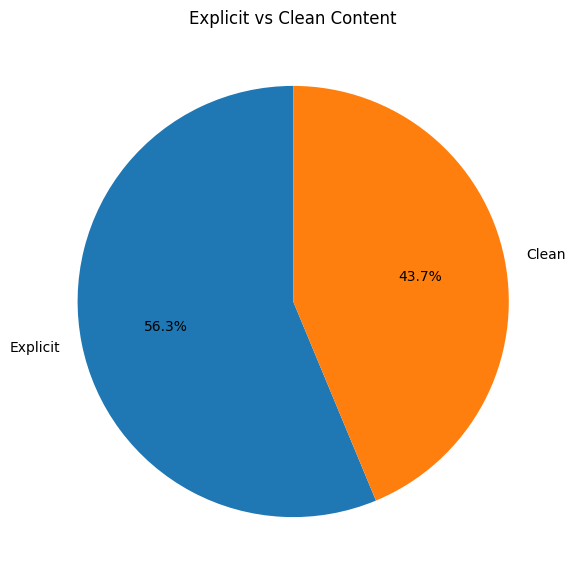

In [ ]:
explicit_distribution = (
    df_clean["is_explicit"]
    .map({True: "Explicit", False: "Clean"})
    .value_counts()
)

display(explicit_distribution)

plt.figure(figsize=(7, 7))
explicit_distribution.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Explicit vs Clean Content")
plt.ylabel("")
plt.show()


In [ ]:
explicit_performance = (
    df_clean
    .groupby("is_explicit")
    .agg(
        average_rank=("position", "mean"),
        median_rank=("position", "median"),
        average_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        track_count=("song", "count")
    )
    .reset_index()
)

explicit_performance["Content"] = (
    explicit_performance["is_explicit"]
    .map({True: "Explicit", False: "Clean"})
)

display(explicit_performance)


,is_explicit,average_rank,median_rank,average_popularity,median_popularity,track_count,Content
0,False,26.157149,26.0,80.904656,81.0,12135,Clean
1,True,24.990778,25.0,73.327206,74.0,15614,Explicit


,is_explicit
rank_group,
1-10,62.443684
11-25,54.534535
26-50,54.839640


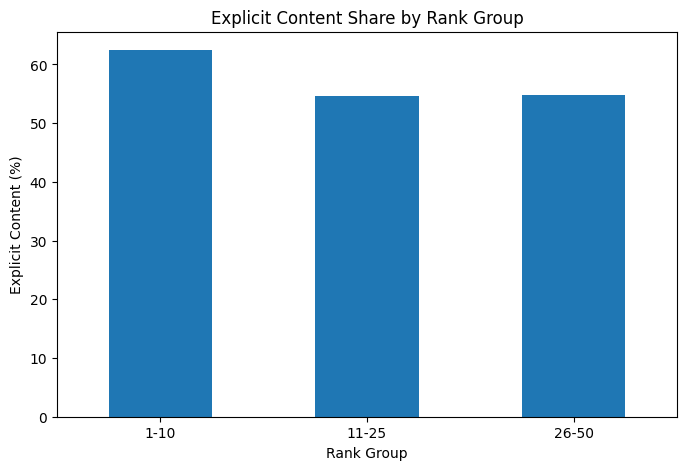

In [ ]:
# Explicit content share by exclusive rank group
explicit_by_group = (
    df_clean
    .groupby("rank_group")["is_explicit"]
    .mean()
    .mul(100)
    .reindex(["1-10", "11-25", "26-50"])
)

display(explicit_by_group)

plt.figure(figsize=(8, 5))
explicit_by_group.plot(kind="bar")
plt.title("Explicit Content Share by Rank Group")
plt.xlabel("Rank Group")
plt.ylabel("Explicit Content (%)")
plt.xticks(rotation=0)
plt.show()


## 10. Explicit vs Clean Statistical Test

In [ ]:
explicit_values = df_clean.loc[
    df_clean["is_explicit"] == True,
    "popularity"
].dropna()

clean_values = df_clean.loc[
    df_clean["is_explicit"] == False,
    "popularity"
].dropna()

t_stat_pop, p_value_pop = stats.ttest_ind(
    explicit_values,
    clean_values,
    equal_var=False
)

print("Explicit vs Clean popularity test")
print("T-statistic:", round(t_stat_pop, 4))
print("P-value:", round(p_value_pop, 6))

if p_value_pop < 0.05:
    print("Interpretation: statistically significant difference at the 5% level.")
else:
    print("Interpretation: no statistically significant difference at the 5% level.")


Explicit vs Clean popularity test
T-statistic: -56.7818
P-value: 0.0
Interpretation: statistically significant difference at the 5% level.


In [ ]:
explicit_rank = df_clean.loc[
    df_clean["is_explicit"] == True,
    "position"
].dropna()

clean_rank = df_clean.loc[
    df_clean["is_explicit"] == False,
    "position"
].dropna()

t_stat_rank, p_value_rank = stats.ttest_ind(
    explicit_rank,
    clean_rank,
    equal_var=False
)

print("Explicit vs Clean chart-rank test")
print("T-statistic:", round(t_stat_rank, 4))
print("P-value:", round(p_value_rank, 6))

if p_value_rank < 0.05:
    print("Interpretation: statistically significant difference at the 5% level.")
else:
    print("Interpretation: no statistically significant difference at the 5% level.")


Explicit vs Clean chart-rank test
T-statistic: -6.7109
P-value: 0.0
Interpretation: statistically significant difference at the 5% level.


## 11. Release Format Analysis

Single tracks: 13068
Album tracks: 14672
Single/Album Ratio: 0.89


,count
album_type,
album,52.891132
single,47.108868


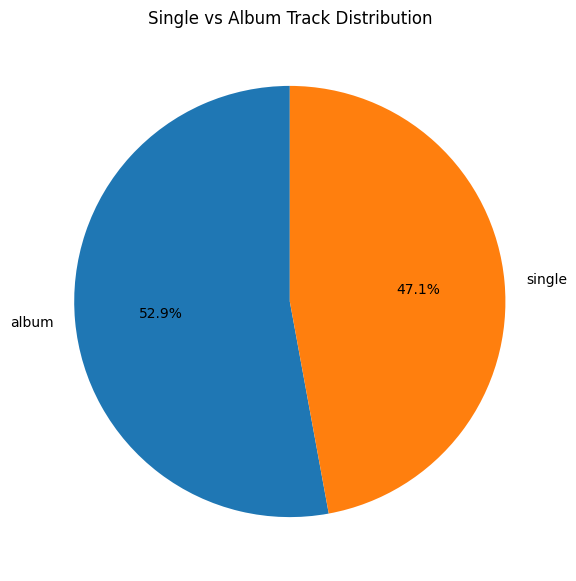

In [ ]:
# Main Single vs Album analysis
format_df = df_clean[
    df_clean["album_type"].isin(["single", "album"])
].copy()

format_counts = format_df["album_type"].value_counts()

single_count = int(format_counts.get("single", 0))
album_count = int(format_counts.get("album", 0))

single_album_ratio = (
    single_count / album_count
    if album_count > 0
    else np.nan
)

print("Single tracks:", single_count)
print("Album tracks:", album_count)
print(f"Single/Album Ratio: {single_album_ratio:.2f}")

format_percent = format_counts / format_counts.sum() * 100
display(format_percent)

plt.figure(figsize=(7, 7))
format_percent.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Single vs Album Track Distribution")
plt.ylabel("")
plt.show()


,average_popularity,median_popularity,average_rank,median_rank,track_count
album_type,,,,,
album,72.982211,73.0,26.728258,28.0,14672
single,80.746863,78.0,24.120600,24.0,13068


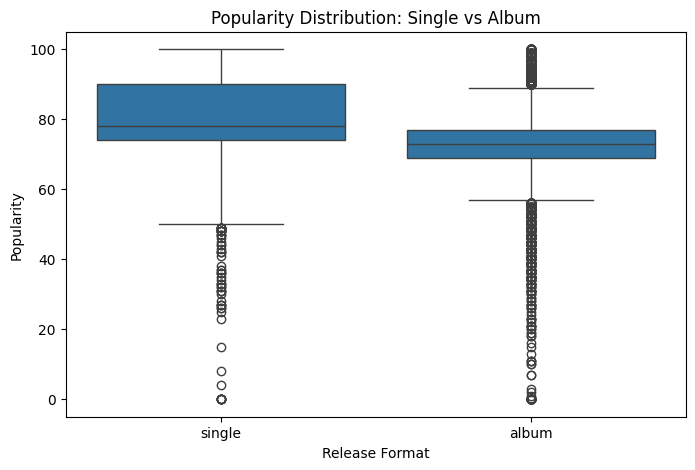

In [ ]:
format_performance = (
    format_df
    .groupby("album_type")
    .agg(
        average_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        average_rank=("position", "mean"),
        median_rank=("position", "median"),
        track_count=("song", "count")
    )
)

display(format_performance)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=format_df,
    x="album_type",
    y="popularity"
)
plt.title("Popularity Distribution: Single vs Album")
plt.xlabel("Release Format")
plt.ylabel("Popularity")
plt.show()


,Tier,Single %,Album %
0,Top 10,50.747883,49.252117
1,Top 25,50.987743,49.012257
2,Top 50,47.108868,52.891132


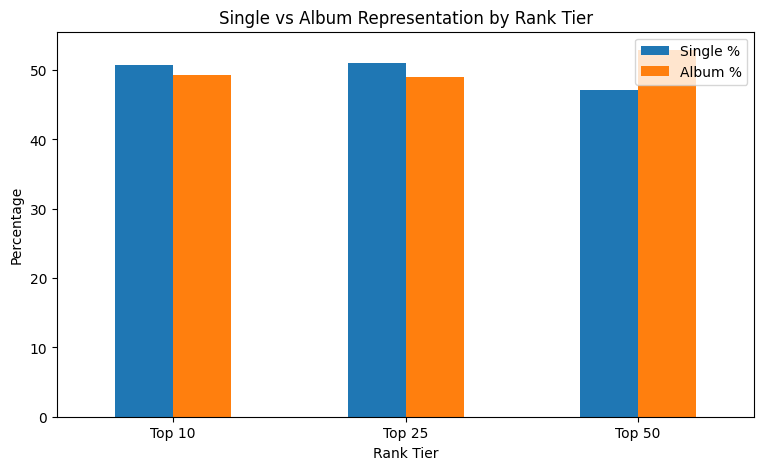

In [ ]:
# Single vs Album representation by rank tier
format_tier_data = []

for tier_name, condition in [
    ("Top 10", df_clean["position"] <= 10),
    ("Top 25", df_clean["position"] <= 25),
    ("Top 50", df_clean["position"] <= 50)
]:
    temp = df_clean[condition]
    temp = temp[temp["album_type"].isin(["single", "album"])]

    percentages = temp["album_type"].value_counts(normalize=True) * 100

    format_tier_data.append({
        "Tier": tier_name,
        "Single %": percentages.get("single", 0),
        "Album %": percentages.get("album", 0)
    })

format_tier_df = pd.DataFrame(format_tier_data)

display(format_tier_df)

format_tier_df.set_index("Tier")[["Single %", "Album %"]].plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title("Single vs Album Representation by Rank Tier")
plt.xlabel("Rank Tier")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()


In [ ]:
# Single vs Album popularity statistical test
single_popularity = format_df.loc[
    format_df["album_type"] == "single",
    "popularity"
].dropna()

album_popularity = format_df.loc[
    format_df["album_type"] == "album",
    "popularity"
].dropna()

t_stat_format, p_value_format = stats.ttest_ind(
    single_popularity,
    album_popularity,
    equal_var=False
)

print("Single vs Album popularity test")
print("T-statistic:", round(t_stat_format, 4))
print("P-value:", round(p_value_format, 6))

if p_value_format < 0.05:
    print("Interpretation: statistically significant difference at the 5% level.")
else:
    print("Interpretation: no statistically significant difference at the 5% level.")


Single vs Album popularity test
T-statistic: 59.4229
P-value: 0.0
Interpretation: statistically significant difference at the 5% level.


## 12. Album Structure Analysis

Album-track records: 14672


,total_tracks
count,14672.000000
mean,15.643811
std,5.101496
min,7.000000
25%,13.000000
50%,15.000000
75%,17.000000
max,40.000000


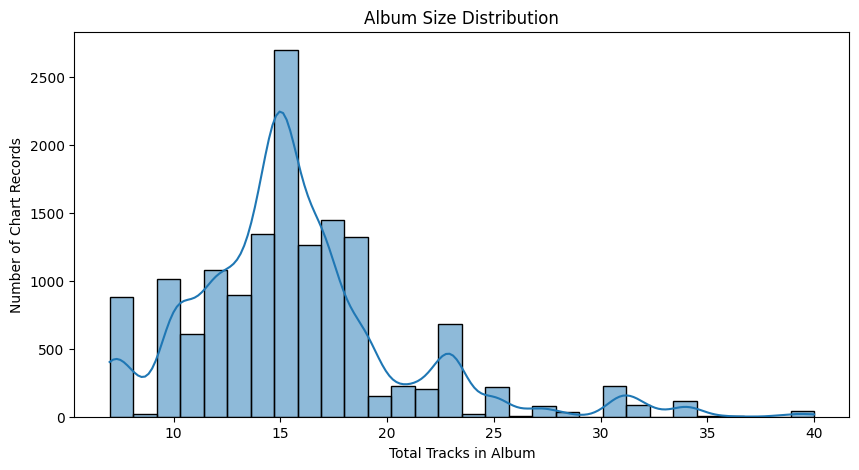

In [ ]:
album_data = df_clean[
    df_clean["album_type"] == "album"
].copy()

print("Album-track records:", len(album_data))
display(album_data["total_tracks"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(
    album_data["total_tracks"],
    bins=30,
    kde=True
)
plt.title("Album Size Distribution")
plt.xlabel("Total Tracks in Album")
plt.ylabel("Number of Chart Records")
plt.show()


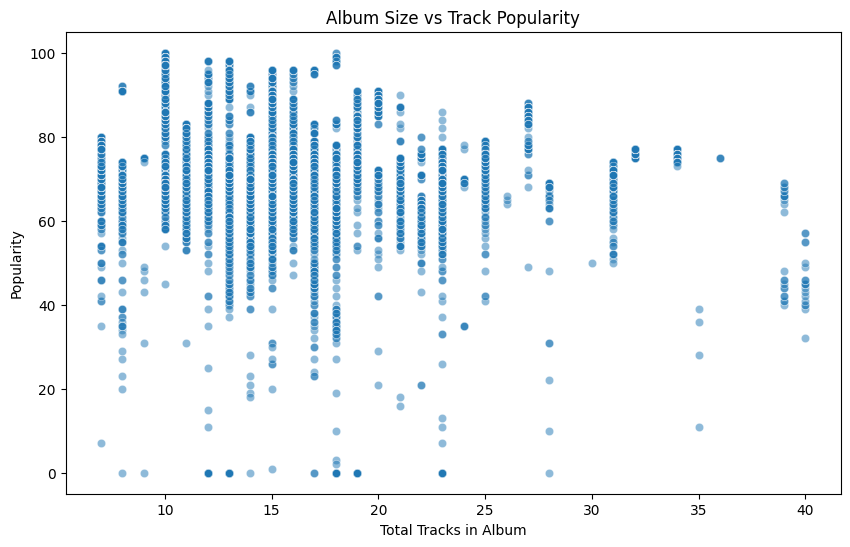

,total_tracks,popularity
total_tracks,1.000000,-0.138402
popularity,-0.138402,1.000000


In [ ]:
# Album size vs popularity
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=album_data,
    x="total_tracks",
    y="popularity",
    alpha=0.5
)
plt.title("Album Size vs Track Popularity")
plt.xlabel("Total Tracks in Album")
plt.ylabel("Popularity")
plt.show()

album_corr = album_data[
    ["total_tracks", "popularity"]
].corr()

display(album_corr)


,album_size_bucket,track_count,average_popularity,median_popularity,average_rank,median_rank
0,Small (1-10),1920,77.044271,73.0,25.643229,25.0
1,Medium (11-15),6621,73.731158,74.0,26.446156,28.0
2,Large (16-20),4180,71.967943,74.0,26.574163,26.0
3,Very Large (21+),1951,68.616094,71.0,29.083547,32.0


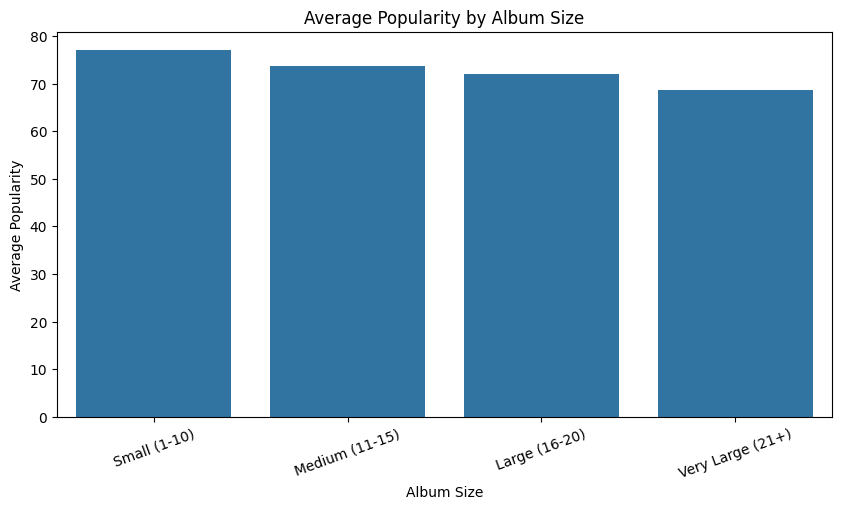

In [ ]:
album_size_performance = (
    album_data
    .groupby("album_size_bucket", observed=True)
    .agg(
        track_count=("song", "count"),
        average_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        average_rank=("position", "mean"),
        median_rank=("position", "median")
    )
    .reset_index()
)

display(album_size_performance)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=album_size_performance,
    x="album_size_bucket",
    y="average_popularity"
)
plt.title("Average Popularity by Album Size")
plt.xlabel("Album Size")
plt.ylabel("Average Popularity")
plt.xticks(rotation=20)
plt.show()


### Album Dilution / Concentration

In [ ]:
# Approximate chart representation rate for artist + album-size combinations.
# This is an observed Top 50 representation metric, not a causal measure.

album_group = (
    album_data
    .groupby(["artist", "total_tracks"])
    .agg(
        chart_tracks=("song", "count"),
        average_popularity=("popularity", "mean")
    )
    .reset_index()
)

album_group["concentration_rate"] = (
    album_group["chart_tracks"] /
    album_group["total_tracks"]
)

print("Average concentration rate:",
      round(album_group["concentration_rate"].mean(), 4))

print("Median concentration rate:",
      round(album_group["concentration_rate"].median(), 4))

display(
    album_group.sort_values(
        "concentration_rate",
        ascending=False
    ).head(20)
)


Average concentration rate: 4.5599
Median concentration rate: 1.1786


,artist,total_tracks,chart_tracks,average_popularity,concentration_rate
67,Gazo & Tiakola,12,482,72.850622,40.166667
205,Werenoi,7,279,70.637993,39.857143
176,SDM,15,575,77.377391,38.333333
190,Teddy Swims,10,339,89.548673,33.900000
14,Booba,10,296,68.787162,29.600000
144,Ninho,16,447,73.901566,27.937500
213,Werenoi,19,525,75.091429,27.631579
49,Favé,15,397,72.345088,26.466667
12,Billie Eilish,10,236,94.546610,23.600000
66,Gazo,15,347,75.095101,23.133333


## 13. Song Duration Analysis

,duration_min
count,27749.000000
mean,3.091412
std,0.540445
min,0.667333
25%,2.759767
50%,3.000000
75%,3.462217
max,9.123550


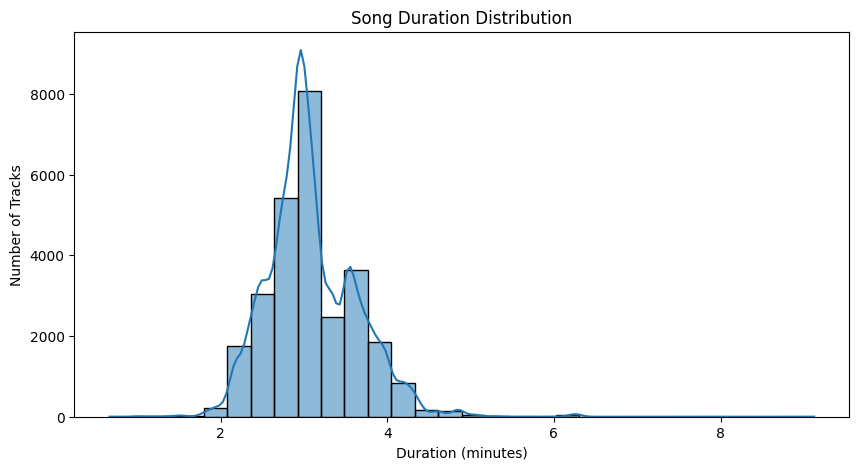

In [ ]:
display(df_clean["duration_min"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(
    df_clean["duration_min"].dropna(),
    bins=30,
    kde=True
)
plt.title("Song Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Tracks")
plt.show()


,duration_bucket,track_count,average_popularity,median_popularity,average_rank,median_rank,explicit_share
0,<2 min,229,75.087336,75.0,29.973799,32.0,89.956332
1,2-3 min,13660,75.566618,75.0,25.552343,25.0,56.266471
2,3-4 min,12360,77.718689,76.0,24.886893,25.0,53.236246
3,>4 min,1500,77.780667,76.0,29.408000,32.0,76.133333


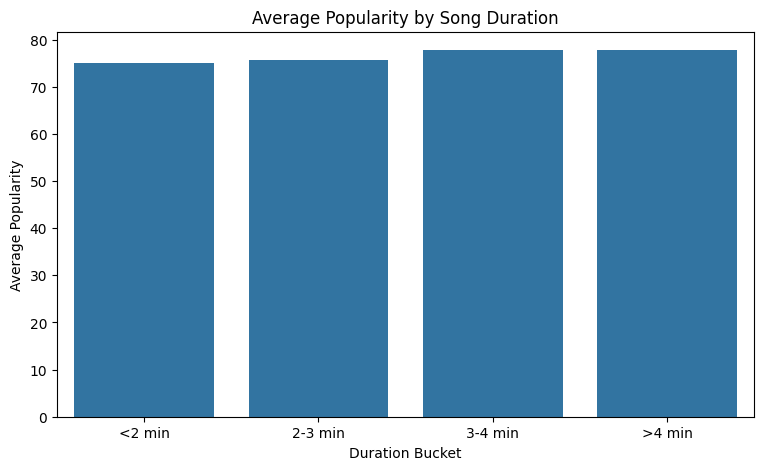

In [ ]:
duration_analysis = (
    df_clean
    .groupby("duration_bucket", observed=True)
    .agg(
        track_count=("song", "count"),
        average_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        average_rank=("position", "mean"),
        median_rank=("position", "median"),
        explicit_share=("is_explicit", "mean")
    )
    .reset_index()
)

duration_analysis["explicit_share"] *= 100

display(duration_analysis)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=duration_analysis,
    x="duration_bucket",
    y="average_popularity"
)
plt.title("Average Popularity by Song Duration")
plt.xlabel("Duration Bucket")
plt.ylabel("Average Popularity")
plt.show()


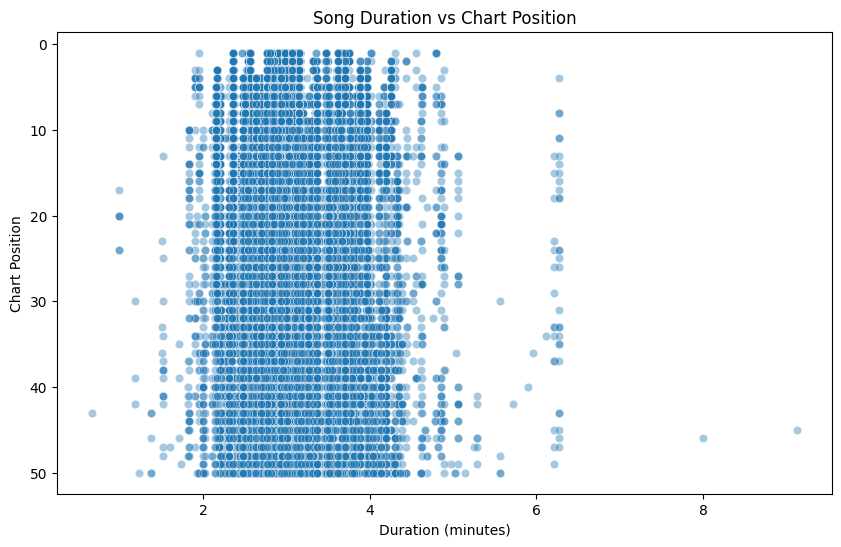

,duration_min,position,popularity
duration_min,1.000000,0.017498,0.054677
position,0.017498,1.000000,-0.118055
popularity,0.054677,-0.118055,1.000000


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="duration_min",
    y="position",
    alpha=0.4
)
plt.gca().invert_yaxis()
plt.title("Song Duration vs Chart Position")
plt.xlabel("Duration (minutes)")
plt.ylabel("Chart Position")
plt.show()

duration_correlation = df_clean[
    ["duration_min", "position", "popularity"]
].corr()

display(duration_correlation)


## 14. Top 10 / Top 25 / Top 50 Content Profile

In [ ]:
profiles = []

for tier, condition in [
    ("Top 10", df_clean["position"] <= 10),
    ("Top 25", df_clean["position"] <= 25),
    ("Top 50", df_clean["position"] <= 50)
]:
    subset = df_clean[condition]

    profiles.append({
        "Rank Tier": tier,
        "Track Count": len(subset),
        "Explicit %": subset["is_explicit"].mean() * 100,
        "Clean %": (~subset["is_explicit"]).mean() * 100,
        "Avg Popularity": subset["popularity"].mean(),
        "Avg Duration (min)": subset["duration_min"].mean(),
        "Avg Album Size": subset["total_tracks"].mean()
    })

profile_df = pd.DataFrame(profiles)

display(profile_df)


,Rank Tier,Track Count,Explicit %,Clean %,Avg Popularity,Avg Duration (min),Avg Album Size
0,Top 10,5549,62.443684,37.556316,78.284195,3.088292,8.043071
1,Top 25,13874,57.697852,42.302148,77.967493,3.084558,8.240954
2,Top 50,27749,56.268694,43.731306,76.640924,3.091412,9.001982


## 15. Content Acceptance Score

### Project-defined formula

Because the brief does not specify an official formula, this notebook uses:

**Rank Score = 100 × (51 − position) / 50**

Then:

**Content Acceptance Score = 0.5 × Rank Score + 0.5 × Popularity**

This is a project-defined composite indicator designed to combine chart placement and API popularity into one 0–100 measure. It should not be presented as an industry-standard KPI.


In [ ]:
# Calculate Content Acceptance Score and compare it across Explicit Status,
# Release Format, and Duration Bucket

# Make sure the score exists
df_clean["rank_score"] = 100 * (51 - df_clean["position"]) / 50

df_clean["content_acceptance_score"] = (
    0.5 * df_clean["rank_score"] +
    0.5 * df_clean["popularity"]
)

# Explicit Status
acceptance_by_explicit = (
    df_clean
    .groupby("is_explicit")["content_acceptance_score"]
    .mean()
    .rename(index={False: "Clean", True: "Explicit"})
)

print("Acceptance Score by Explicit Status")
display(acceptance_by_explicit)

# Release Format
# Recreate format_df so the newly-created score is included
format_df = df_clean[
    df_clean["album_type"].isin(["single", "album"])
].copy()

print("\nAcceptance Score by Format")
acceptance_by_format = (
    format_df
    .groupby("album_type")["content_acceptance_score"]
    .mean()
)

display(acceptance_by_format)

# Duration Bucket
print("\nAcceptance Score by Duration")
acceptance_by_duration = (
    df_clean
    .groupby("duration_bucket", observed=True)["content_acceptance_score"]
    .mean()
)

display(acceptance_by_duration)

Acceptance Score by Explicit Status


,content_acceptance_score
is_explicit,
Clean,65.295179
Explicit,62.672826



Acceptance Score by Format


,content_acceptance_score
album_type,
album,60.762848
single,67.252831



Acceptance Score by Duration


,content_acceptance_score
duration_bucket,
<2 min,58.569869
2-3 min,63.230966
3-4 min,64.972451
>4 min,60.482333


## 16. Album Size Impact Index

### Project-defined formula

For this project:

**Small album = 10 tracks or fewer**

**Large album = more than 10 tracks**

**Album Size Impact Index = Mean popularity of large-album tracks − Mean popularity of small-album tracks**

Positive values mean large-album tracks have higher average popularity; negative values mean lower average popularity.


In [ ]:
large_album_mean = album_data.loc[
    album_data["total_tracks"] > 10,
    "popularity"
].mean()

small_album_mean = album_data.loc[
    album_data["total_tracks"] <= 10,
    "popularity"
].mean()

album_size_impact = large_album_mean - small_album_mean

print("Small album average popularity:",
      round(small_album_mean, 2))

print("Large album average popularity:",
      round(large_album_mean, 2))

print("Album Size Impact Index:",
      round(album_size_impact, 2))


Small album average popularity: 77.04
Large album average popularity: 72.37
Album Size Impact Index: -4.67


## 17. Monthly Trend Analysis

In [ ]:
df_clean["month"] = (
    df_clean["date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_analysis = (
    df_clean
    .groupby("month")
    .agg(
        explicit_share=("is_explicit", "mean"),
        average_popularity=("popularity", "mean"),
        average_duration=("duration_min", "mean"),
        average_rank=("position", "mean"),
        average_album_size=("total_tracks", "mean")
    )
    .reset_index()
)

monthly_analysis["explicit_share"] *= 100

display(monthly_analysis.head())


,month,explicit_share,average_popularity,average_duration,average_rank,average_album_size
0,2024-05,56.857143,77.274286,3.133082,25.5,10.365714
1,2024-06,62.666667,76.628667,3.167781,25.5,10.372667
2,2024-07,63.483871,76.710968,3.171155,25.5,11.545806
3,2024-08,55.032258,78.793548,3.101100,25.5,9.009677
4,2024-09,66.533333,77.024667,3.244872,25.5,8.774667


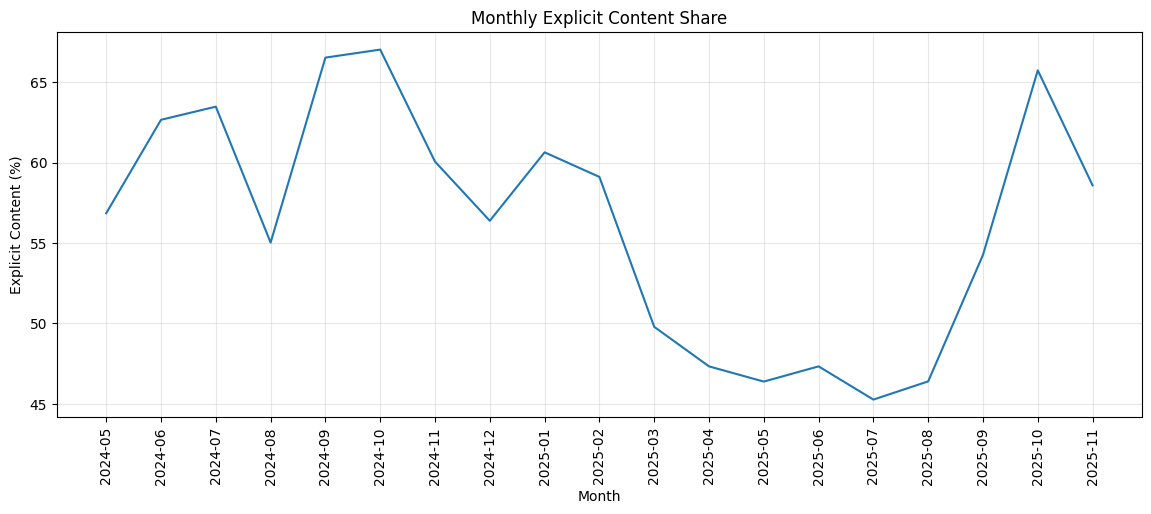

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(
    monthly_analysis["month"],
    monthly_analysis["explicit_share"]
)
plt.title("Monthly Explicit Content Share")
plt.xlabel("Month")
plt.ylabel("Explicit Content (%)")
plt.xticks(rotation=90)
plt.grid(alpha=0.3)
plt.show()


album_type,album,single,total,single_pct,album_pct
month,,,,,
2024-05,413,287,700,41.000000,59.000000
2024-06,838,662,1500,44.133333,55.866667
2024-07,963,587,1550,37.870968,62.129032
2024-08,744,806,1550,52.000000,48.000000
2024-09,776,724,1500,48.266667,51.733333


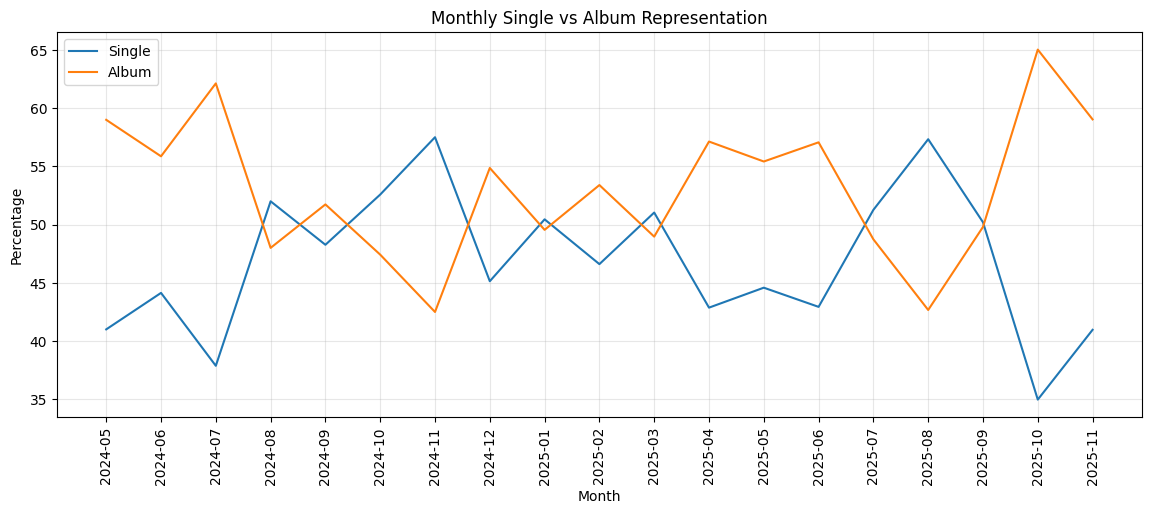

In [ ]:
monthly_format = (
    format_df.assign(
        month=format_df["date"].dt.to_period("M").astype(str)
    )
    .groupby(["month", "album_type"])
    .size()
    .unstack(fill_value=0)
)

monthly_format["total"] = monthly_format.sum(axis=1)

monthly_format["single_pct"] = (
    monthly_format.get("single", 0)
    / monthly_format["total"]
    * 100
)

monthly_format["album_pct"] = (
    monthly_format.get("album", 0)
    / monthly_format["total"]
    * 100
)

display(monthly_format.head())

plt.figure(figsize=(14, 5))
plt.plot(
    monthly_format.index,
    monthly_format["single_pct"],
    label="Single"
)
plt.plot(
    monthly_format.index,
    monthly_format["album_pct"],
    label="Album"
)
plt.title("Monthly Single vs Album Representation")
plt.xlabel("Month")
plt.ylabel("Percentage")
plt.xticks(rotation=90)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 18. Correlation Analysis

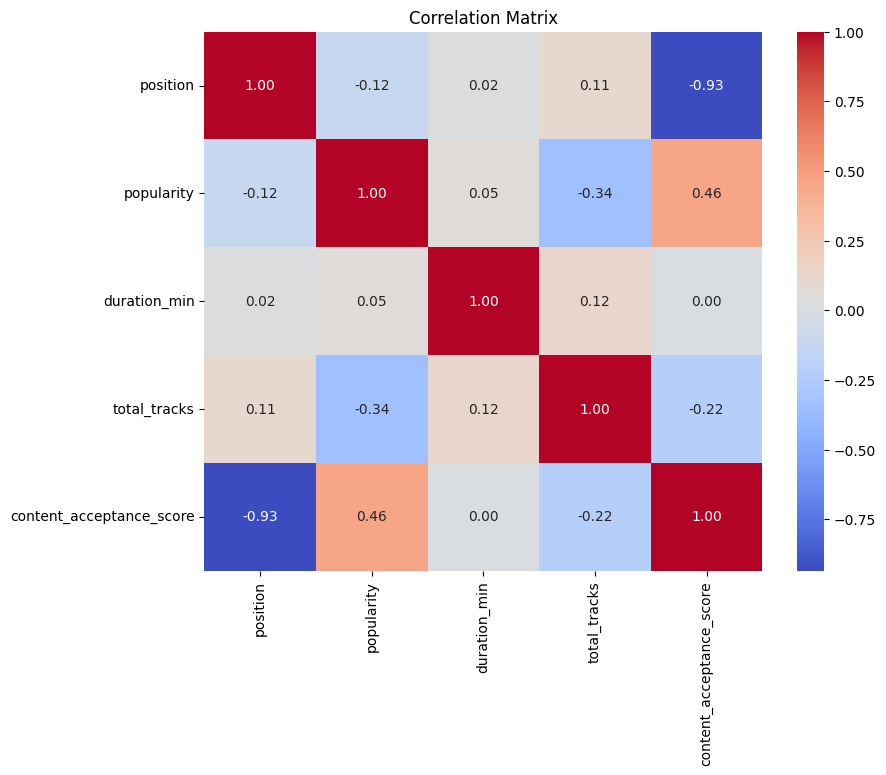

In [ ]:
corr_columns = [
    "position",
    "popularity",
    "duration_min",
    "total_tracks",
    "content_acceptance_score"
]

corr_matrix = df_clean[corr_columns].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()


## 19. Executive KPI Summary

In [ ]:
kpi_table = pd.DataFrame({
    "KPI": [
        "Explicit Content Share",
        "Clean Content Share",
        "Clean Dominance Ratio",
        "Single vs Album Ratio",
        "Average Song Duration",
        "Average Popularity",
        "Album Size Impact Index",
        "Average Content Acceptance Score"
    ],
    "Value": [
        f"{explicit_share:.2f}%",
        f"{clean_share:.2f}%",
        f"{clean_dominance_ratio:.2f}",
        f"{single_album_ratio:.2f}",
        f"{average_duration:.2f} min",
        f"{average_popularity:.2f}",
        f"{album_size_impact:.2f}",
        f"{df_clean['content_acceptance_score'].mean():.2f}"
    ]
})

display(kpi_table)


,KPI,Value
0,Explicit Content Share,56.27%
1,Clean Content Share,43.73%
2,Clean Dominance Ratio,0.78
3,Single vs Album Ratio,0.89
4,Average Song Duration,3.09 min
5,Average Popularity,76.64
6,Album Size Impact Index,-4.67
7,Average Content Acceptance Score,63.82


## 20. Automatically Generated Key Findings

In [ ]:
# Derive a few data-driven findings for use as a starting point.
best_duration_row = duration_analysis.loc[
    duration_analysis["average_popularity"].idxmax()
]

best_album_row = album_size_performance.loc[
    album_size_performance["average_popularity"].idxmax()
]

top10 = df_clean[df_clean["position"] <= 10]

print("KEY FINDINGS")
print("=" * 70)

print(
    f"1. Explicit tracks represent {explicit_share:.2f}% "
    f"of the cleaned France Top 50 records."
)

print(
    f"2. Average popularity is {explicit_values.mean():.2f} "
    f"for explicit tracks versus {clean_values.mean():.2f} "
    f"for clean tracks."
)

print(
    f"3. Average chart position is {explicit_rank.mean():.2f} "
    f"for explicit tracks versus {clean_rank.mean():.2f} "
    f"for clean tracks. Lower position is better."
)

print(
    f"4. Among Single/Album records, singles account for "
    f"{single_count / len(format_df) * 100:.2f}%."
)

print(
    f"5. Average song duration is {average_duration:.2f} minutes."
)

print(
    f"6. The duration bucket with the highest average popularity is "
    f"{best_duration_row['duration_bucket']} "
    f"({best_duration_row['average_popularity']:.2f})."
)

print(
    f"7. The album-size bucket with the highest average popularity is "
    f"{best_album_row['album_size_bucket']} "
    f"({best_album_row['average_popularity']:.2f})."
)

print(
    f"8. Top 10 average Content Acceptance Score is "
    f"{top10['content_acceptance_score'].mean():.2f}."
)


KEY FINDINGS
1. Explicit tracks represent 56.27% of the cleaned France Top 50 records.
2. Average popularity is 73.33 for explicit tracks versus 80.90 for clean tracks.
3. Average chart position is 24.99 for explicit tracks versus 26.16 for clean tracks. Lower position is better.
4. Among Single/Album records, singles account for 47.11%.
5. Average song duration is 3.09 minutes.
6. The duration bucket with the highest average popularity is >4 min (77.78).
7. The album-size bucket with the highest average popularity is Small (1-10) (77.04).
8. Top 10 average Content Acceptance Score is 84.64.


## 21. Optional Regression Analysis

This optional model explores whether duration, album size, explicit status and album type are associated with API popularity.

It is **not** proof of causality and should be presented as supporting analysis.


In [ ]:
model_df = df_clean[
    [
        "popularity",
        "duration_min",
        "total_tracks",
        "is_explicit",
        "album_type"
    ]
].dropna().copy()

model_df["is_explicit"] = model_df["is_explicit"].astype(int)

X = model_df[
    [
        "duration_min",
        "total_tracks",
        "is_explicit",
        "album_type"
    ]
]

y = model_df["popularity"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "album_type",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            ["album_type"]
        )
    ],
    remainder="passthrough"
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("R² Score:", round(r2, 3))
print("RMSE:", round(rmse, 3))


R² Score: 0.172
RMSE: 10.451


## 22. Export Analysis Tables

In [ ]:
# Export important result tables for the research paper and dashboard
outputs = {
    "kpi_summary.csv": kpi_table,
    "rank_tier_content_profile.csv": profile_df,
    "format_by_rank_tier.csv": format_tier_df,
    "duration_analysis.csv": duration_analysis,
    "album_size_analysis.csv": album_size_performance,
    "monthly_analysis.csv": monthly_analysis,
    "album_concentration.csv": album_group
}

for filename, table in outputs.items():
    table.to_csv(filename, index=False)

print("Exported files:")
for filename in outputs:
    print(" -", filename)


Exported files:
 - kpi_summary.csv
 - rank_tier_content_profile.csv
 - format_by_rank_tier.csv
 - duration_analysis.csv
 - album_size_analysis.csv
 - monthly_analysis.csv
 - album_concentration.csv


## 23. Streamlit Dashboard

The next cell creates a complete `app.py` file.

### Colab note
Streamlit normally runs as a web server rather than inside a normal notebook output cell. We therefore run Streamlit on port 8501 and expose it with an ngrok tunnel.


## 24. Run Streamlit in Google Colab

# Stramlit on Browser

In [ ]:
# ============================================================
# STREAMLIT IN A NEW BROWSER TAB FROM GOOGLE COLAB
# ============================================================

import os
import time
import socket
import webbrowser
from pathlib import Path
from pyngrok import ngrok
from getpass import getpass

# ------------------------------------------------------------
# 1. Check required files
# ------------------------------------------------------------

if not Path("/content/app.py").exists():
    raise FileNotFoundError("app.py is missing from /content/")

if not Path("/content/cleaned_france_top50.csv").exists():
    raise FileNotFoundError(
        "cleaned_france_top50.csv is missing from /content/"
    )

print("✅ app.py found")
print("✅ cleaned_france_top50.csv found")

# ------------------------------------------------------------
# 2. Stop previous processes
# ------------------------------------------------------------

os.system("pkill -f streamlit >/dev/null 2>&1 || true")

try:
    ngrok.kill()
except:
    pass

time.sleep(2)

# ------------------------------------------------------------
# 3. Start Streamlit
# ------------------------------------------------------------

print("\n🚀 Starting Streamlit...")

os.system(
    "nohup streamlit run /content/app.py "
    "--server.address=0.0.0.0 "
    "--server.port=8501 "
    "--server.headless=true "
    "--server.enableCORS=false "
    "--server.enableXsrfProtection=false "
    "> /content/streamlit.log 2>&1 &"
)

# ------------------------------------------------------------
# 4. Wait for Streamlit
# ------------------------------------------------------------

print("⏳ Waiting for Streamlit to start...")

ready = False

for _ in range(30):

    time.sleep(1)

    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.settimeout(1)

    try:
        sock.connect(("127.0.0.1", 8501))
        ready = True
        sock.close()
        break
    except:
        sock.close()

if not ready:

    print("\n❌ Streamlit failed to start.\n")
    print("=" * 70)

    if Path("/content/streamlit.log").exists():
        with open(
            "/content/streamlit.log",
            "r",
            encoding="utf-8",
            errors="ignore"
        ) as f:
            print(f.read())

    raise RuntimeError("Streamlit did not start.")

print("✅ Streamlit is running on port 8501")

# ------------------------------------------------------------
# 5. Authenticate ngrok
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NGROK AUTHENTICATION")
print("=" * 70)

print(
    "Get your token from:\n"
    "https://dashboard.ngrok.com/get-started/your-authtoken"
)

token = getpass("\nPaste your ngrok Authtoken: ").strip()

if not token:
    raise ValueError("ngrok Authtoken is required.")

ngrok.set_auth_token(token)

# ------------------------------------------------------------
# 6. Create tunnel
# ------------------------------------------------------------

print("\n🌐 Creating public tunnel...")

public_url = ngrok.connect(
    addr=8501,
    proto="http"
)

url = str(public_url)

print("\n" + "=" * 70)
print("✅ STREAMLIT DASHBOARD IS LIVE")
print("=" * 70)
print("Dashboard URL:")
print(url)
print("=" * 70)

# ------------------------------------------------------------
# 7. Open in a NEW browser tab
# ------------------------------------------------------------

webbrowser.open_new_tab(url)

print("\n🖥️ Opening dashboard in a new browser tab...")

✅ app.py found
✅ cleaned_france_top50.csv found

🚀 Starting Streamlit...
⏳ Waiting for Streamlit to start...
✅ Streamlit is running on port 8501

NGROK AUTHENTICATION
Get your token from:
https://dashboard.ngrok.com/get-started/your-authtoken

Paste your ngrok Authtoken: ··········

🌐 Creating public tunnel...

✅ STREAMLIT DASHBOARD IS LIVE
Dashboard URL:
NgrokTunnel: "https://stardom-whimsical-astute.ngrok-free.dev" -> "http://localhost:8501"

🖥️ Opening dashboard in a new browser tab...


## 25. Download Project Outputs

The following cells download the main files from Colab.


In [ ]:
# Download cleaned dataset
files.download("cleaned_france_top50.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Download Streamlit application
files.download("app.py")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Create a ZIP containing the main project outputs
import zipfile

project_files = [
    "cleaned_france_top50.csv",
    "kpi_summary.csv",
    "rank_tier_content_profile.csv",
    "format_by_rank_tier.csv",
    "duration_analysis.csv",
    "album_size_analysis.csv",
    "monthly_analysis.csv",
    "album_concentration.csv",
    "app.py"
]

with zipfile.ZipFile(
    "Atlantic_France_Project_Outputs.zip",
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:
    for filename in project_files:
        if Path(filename).exists():
            zipf.write(filename)

print("Created Atlantic_France_Project_Outputs.zip")


Created Atlantic_France_Project_Outputs.zip


In [ ]:
files.download("Atlantic_France_Project_Outputs.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# # ============================================================
# # STREAMLIT DIRECTLY IN GOOGLE COLAB
# # NO NGROK REQUIRED
# # ============================================================

# import os
# import time
# import subprocess
# from pathlib import Path
# from google.colab import output
# from IPython.display import display, HTML

# # ------------------------------------------------------------
# # 1. Check files
# # ------------------------------------------------------------

# print("=" * 60)
# print("CHECKING FILES")
# print("=" * 60)

# for filename in [
#     "app.py",
#     "cleaned_france_top50.csv"
# ]:
#     exists = Path(f"/content/{filename}").exists()
#     print(f"{filename}: {'OK' if exists else 'MISSING'}")

# if not Path("/content/app.py").exists():
#     raise FileNotFoundError("app.py not found.")

# if not Path("/content/cleaned_france_top50.csv").exists():
#     raise FileNotFoundError("cleaned_france_top50.csv not found.")

# # ------------------------------------------------------------
# # 2. Stop old processes
# # ------------------------------------------------------------

# print("\nStopping old Streamlit processes...")

# os.system("pkill -f streamlit >/dev/null 2>&1 || true")
# time.sleep(2)

# # ------------------------------------------------------------
# # 3. Start Streamlit
# # ------------------------------------------------------------

# print("Starting Streamlit...")

# log_path = "/content/streamlit.log"

# with open(log_path, "w") as log_file:

#     process = subprocess.Popen(
#         [
#             "streamlit",
#             "run",
#             "/content/app.py",
#             "--server.address=0.0.0.0",
#             "--server.port=8501",
#             "--server.headless=true",
#             "--server.enableCORS=false",
#             "--server.enableXsrfProtection=false"
#         ],
#         stdout=log_file,
#         stderr=subprocess.STDOUT
#     )

# # ------------------------------------------------------------
# # 4. Wait for Streamlit to start
# # ------------------------------------------------------------

# print("Waiting for Streamlit...")

# ready = False

# for i in range(30):

#     time.sleep(1)

#     # Check whether process is still alive
#     if process.poll() is not None:
#         break

#     # Check whether port is responding
#     import socket

#     sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
#     sock.settimeout(1)

#     try:
#         sock.connect(("127.0.0.1", 8501))
#         ready = True
#         sock.close()
#         break
#     except:
#         sock.close()

# # ------------------------------------------------------------
# # 5. Show error if Streamlit crashed
# # ------------------------------------------------------------

# if not ready:

#     print("\n" + "=" * 60)
#     print("STREAMLIT FAILED TO START")
#     print("=" * 60)

#     if Path(log_path).exists():

#         with open(
#             log_path,
#             "r",
#             encoding="utf-8",
#             errors="ignore"
#         ) as f:

#             print(f.read()[-10000:])

#     raise RuntimeError(
#         "Streamlit did not start. Check the error above."
#     )

# print("Streamlit is running on port 8501.")

# # ------------------------------------------------------------
# # 6. Use Colab's built-in port proxy
# # ------------------------------------------------------------

# print("\nOpening Streamlit inside Colab...")

# output.serve_kernel_port_as_iframe(
#     8501,
#     width="100%",
#     height="900"
# )

# print("\nDashboard loaded below.")